In [20]:
from torchvision import transforms,models,datasets
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from pathlib import Path
import torch
import numpy as np
from PIL import Image
import os
from torch import nn
from torchvision.models import vit_b_16
import torch.optim as optim
# from ..opt import read_args
from five_dataset import MyDataset
from models.vit import DualVisionTransformer
from models.resnet18 import DualResNet
from models.vgg import DualVgg16
import time
from torch.utils.data import random_split
from plot_image import plot_image
from torch.utils.tensorboard import SummaryWriter
from main import load_dataset,criterion1,criterion2
import random
random.seed(42) 


_,_,test_dataset=load_dataset(data_argumentation=True)


this is label2 counter:  Counter({0: 6093, 3: 4407, 1: 1656, 2: 495})
max label2 count:  6093
total num before first balance:  12651
Deep:  6093
Lobar:  1656
Subtentorial:  495
total num after first balance:  21408
counter after first balance:  Counter({0: 6093, 2: 5940, 1: 4968, 3: 4407})
total num before second balance:  21408
no tumor:  4407
tumor:  17001
max label1 count:  17001
total num after balance:  30222
no tumor:  13221
tumor:  17001


In [19]:

def test(model_path,model_type):
    device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)
    if model_type==0:
        model = DualVisionTransformer(
            image_size=224,  
            patch_size=16,
            num_layers=12,
            num_heads=12,
            hidden_dim=768,
            mlp_dim=3072,
            dropout=0.1,
            attention_dropout=0.1,
            num_classe1=2,
            num_classe2=4,
        )
    elif model_type==1:
        model = DualResNet(num_class1=2, num_class2=4)
    elif model_type==2:
        model = DualVgg16(num_class1=2, num_class2=4)
    elif model_type==4:
            model = DualVisionTransformer(
            image_size=224,
            patch_size=16,
            num_layers=12,
            num_heads=12,
            hidden_dim=768,
            mlp_dim=3072,
            dropout=0.1,
            attention_dropout=0.1,
            num_classe1=2,
            num_classe2=4,
            representation_size=768,
        )

    model.load_state_dict(torch.load(model_path))
    ##Testing
    model.eval()
    model.to(device)
    start_time = time.time()
# 
    TP=0
    TN=0
    FP=0
    FN=0
    # 
    C00=0
    C01=0   
    C02=0
    C10=0
    C11=0
    C12=0
    C20=0
    C21=0
    C22=0
    positive_count=0
    negative_count=0
    deep_count=0
    lobar_count=0
    subtentorial_count=0
    # {'Deep': 0, 'Lobar': 1, 'Subtentorial': 2}
    with torch.no_grad():
        running_loss = 0.
        running_corrects = 0
        for index, inputs  in enumerate(test_dataloader):
            image, labels1,labels2 = inputs['pixel_values'],inputs['label1'],inputs['label2']
            image = image.to(device)
            labels1= labels1.to(device)
            labels2= labels2.to(device)
            outputs1,outputs2  = model(image)
            _, preds1 = torch.max(outputs1, 1)
            _, preds2 = torch.max(outputs2, 1)
            # batch loss
            loss1 = criterion1(outputs1, labels1)
            loss2 = criterion2(outputs2, labels2)
            # loss = loss1 + loss2
            loss = loss1 + loss2
            # total loss
            running_loss += loss.item() * image.size(0)
            # positive or negetive
            running_corrects += torch.sum(preds1 == labels1.data)
            # confusion matrix for class1
            for i in range(len(preds1)):
                if preds1[i]==labels1[i]:
                    # no: 0, yes: 1
                    if preds1[i]==0:
                        negative_count+=1
                        TP+=1
                    else:
                        positive_count+=1
                        TN+=1
                else:
                    if preds1[i]==0:
                        positive_count+=1
                        FP+=1
                    else:
                        negative_count+=1
                        FN+=1
            # confusion matrix for class2
            for i in range(len(preds2)):
                if preds2[i]==labels2[i]:
                    if preds2[i]==0:
                        C00+=1
                        deep_count+=1
                    elif preds2[i]==1:
                        C11+=1
                        lobar_count+=1
                    elif preds2[i]==2:
                        C22+=1
                        subtentorial_count+=1
                # predict 和 label不一样
                else:
                    # 后一个数字是预测值，前一个数字是真实值
                    if preds2[i]==0:
                        if labels2[i]==1:
                            lobar_count+=1
                            C10+=1
                        elif labels2[i]==2:
                            subtentorial_count+=1
                            C20+=1
                    elif preds2[i]==1:
                        if labels2[i]==0:
                            deep_count+=1
                            C11+=1
                        elif labels2[i]==2:
                            subtentorial_count+=1
                            C21+=1
                    elif preds2[i]==2:
                        if labels2[i]==0:
                            deep_count+=1
                            C02+=1
                        elif labels2[i]==1:
                            lobar_count+=1
                            C12+=1

            running_corrects += torch.sum(preds2 == labels2.data)
            if index == 0:
                print("label1:",labels1.tolist())
                print("preds1:",preds1.tolist())
                print("label2:",labels2.tolist())
                print("preds2:",preds2.tolist())
                plot_image(image, labels1.tolist(), labels2.tolist(), preds1.tolist(), preds2.tolist())
        epoch_loss = running_loss / len(test_dataset)
        epoch_acc = running_corrects / (2* len(test_dataset)) * 100.
        print('[Test] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.
            format(epoch_loss, epoch_acc, time.time() - start_time))
    print('TP:',TP)
    print('TN:',TN)
    print('FP:',FP)
    print('FN:',FN)
    print("deep count",deep_count)
    print("lobar count",lobar_count)
    print("subtentorial count",subtentorial_count)
    print("positive count",positive_count)
    print("negative count",negative_count)
    return TP,TN,FP,FN,C00,C01,C02,C10,C11,C12,C20,C21,C22


this is label2 counter:  Counter({0: 6093, 3: 4407, 1: 1656, 2: 495})
max label2 count:  6093
total num before first balance:  12651
Deep:  6093
Lobar:  1656
Subtentorial:  495
total num after first balance:  21408
counter after first balance:  Counter({0: 6093, 2: 5940, 1: 4968, 3: 4407})
total num before second balance:  21408
no tumor:  4407
tumor:  17001
max label1 count:  17001
total num after balance:  30222
no tumor:  13221
tumor:  17001


## ViT augumented

label1: [0, 0, 1, 1]
preds1: [0, 0, 1, 1]
label2: [3, 3, 0, 1]
preds2: [3, 3, 0, 1]


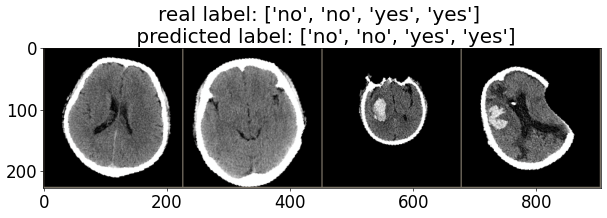

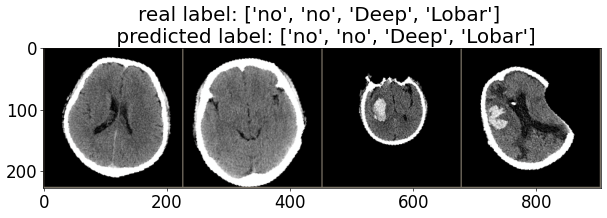

[Test] Loss: 0.1123 Acc: 97.8333% Time: 16.4523s
TP: 1324
TN: 1676
FP: 5
FN: 18
deep count 601
lobar count 479
subtentorial count 596
positive count 1681
negative count 1342
TP: 1324
TN: 1676
FP: 5
FN: 18
Accuracy: 0.9923916639100232
Precision: 0.9962377727614747
Recall: 0.9865871833084948
F1: 0.9913889928865594
Specificity: 0.9970255800118977
C00: 543
C01: 0
C02: 17
C10: 19
C11: 499
C12: 2
C20: 2
C21: 4
C22: 590
Accuracy: 0.9737470167064439
Precision: 0.9627659574468085
Recall: 0.9696428571428571
F1: 0.9661921708185054
Specificity: 0.9945205479452055


In [13]:

home_dir='/disk2/jialiangfan/trained_models/'


# vit model
model_name='dataset2-epoche_50-model_type_0-pretrained_False-argumentation_True-batch_size_32-optimizer_type-0.pth'
# model_name='dataset2-epoche_50-model_type_2-pretrained_False-argumentation_True-batch_size_32-optimizer_type-0.pth'

model_type=0
TP,TN,FP,FN, C00,C01,C02,C10,C11,C12,C20,C21,C22 =test(home_dir+model_name,0)

# draw the confusion matrix
print('TP:',TP)
print('TN:',TN)
print('FP:',FP)
print('FN:',FN)

print('Accuracy:',(TP+TN)/(TP+TN+FP+FN))
print('Precision:',TP/(TP+FP))
print('Recall:',TP/(TP+FN))
print('F1:',2*TP/(2*TP+FP+FN))
print('Specificity:',TN/(TN+FP))

print('C00:',C00)
print('C01:',C01)
print('C02:',C02)
print('C10:',C10)
print('C11:',C11)
print('C12:',C12)
print('C20:',C20)
print('C21:',C21)
print('C22:',C22)

print('Accuracy:',(C00+C11+C22)/(C00+C01+C02+C10+C11+C12+C20+C21+C22))
print('Precision:',C00/(C00+C10+C20))
print('Recall:',C00/(C00+C01+C02))
print('F1:',2*C00/(2*C00+C01+C02+C10+C20))
print('Specificity:',(C11+C22)/(C11+C12+C21+C22))


## Draw the confusion matrix for ViT

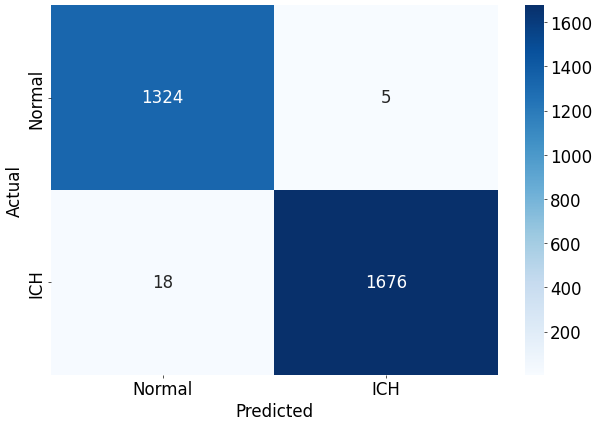

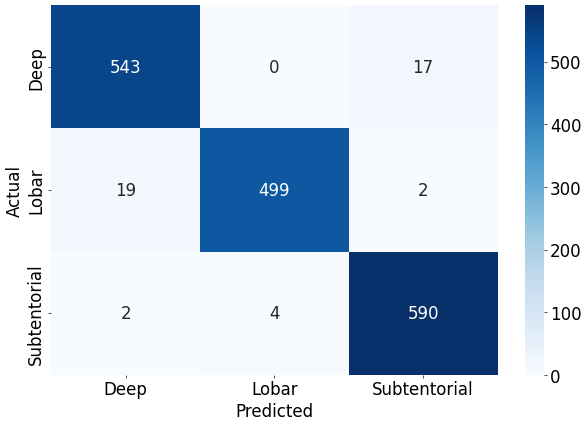

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# 创建混淆矩阵
confusion_matrix1 = np.array([[TP, FP], [FN, TN]])
font_dict={'family':'Times New Roman','size':15}
labels=['Normal','ICH']
# 使用seaborn绘制混淆矩阵
sns.heatmap(confusion_matrix1, annot=True, fmt='d', cmap='Blues',xticklabels=labels, yticklabels=labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('figs/confusion_matrix_class1.png',dpi=300,bbox_inches='tight')
plt.show()


# 创建混淆矩阵
confusion_matrix2 = np.array([[C00, C01,C02], [C10, C11,C12],[C20, C21,C22]])
font_dict={'family':'Times New Roman','size':15}
labels=['Deep','Lobar','Subtentorial']
# {0:'Deep',1:'Lobar',2:'Subtentorial',3:'no'}
# 使用seaborn绘制混淆矩阵
sns.heatmap(confusion_matrix2, annot=True, fmt='d', cmap='Blues',xticklabels=labels, yticklabels=labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('figs/confusion_matrix_class2.png',dpi=300,bbox_inches='tight')
plt.show()

## Vit without augumentation

label1: [1, 1, 1, 1]
preds1: [0, 1, 0, 1]
label2: [0, 2, 2, 2]
preds2: [3, 2, 3, 2]


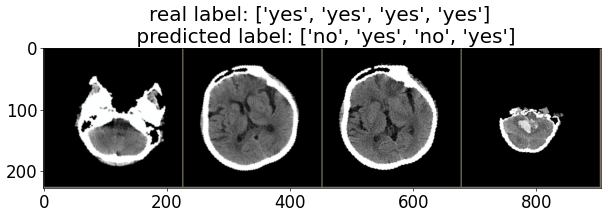

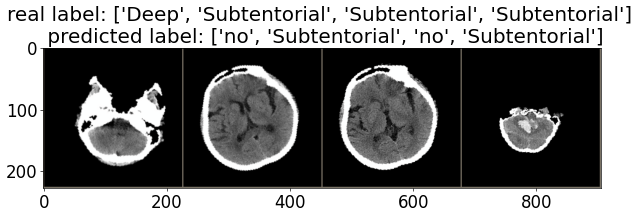

[Test] Loss: 0.2915 Acc: 94.2110% Time: 16.4571s
TP: 1347
TN: 1600
FP: 65
FN: 11
deep count 561
lobar count 485
subtentorial count 556
positive count 1665
negative count 1358
TP: 1347
TN: 1600
FP: 65
FN: 11
Accuracy: 0.9748594111809461
Precision: 0.9539660056657224
Recall: 0.991899852724595
F1: 0.9725631768953069
Specificity: 0.960960960960961
C00: 549
C01: 0
C02: 7
C10: 115
C11: 369
C12: 6
C20: 62
C21: 6
C22: 488
Accuracy: 0.8776529338327091
Precision: 0.756198347107438
Recall: 0.987410071942446
F1: 0.8564742589703588
Specificity: 0.9861910241657077


In [21]:

home_dir='/disk2/jialiangfan/trained_models/'


# vit model
model_name='dataset-epoche_50-model_type_0-pretrained_False-argumentation_False-batch_size_8-optimizer_type-0.pth'
# model_name='dataset2-epoche_50-model_type_2-pretrained_False-argumentation_True-batch_size_32-optimizer_type-0.pth'
model_type=4
TP,TN,FP,FN, C00,C01,C02,C10,C11,C12,C20,C21,C22 =test(home_dir+model_name,model_type)

# draw the confusion matrix
print('TP:',TP)
print('TN:',TN)
print('FP:',FP)
print('FN:',FN)

print('Accuracy:',(TP+TN)/(TP+TN+FP+FN))
print('Precision:',TP/(TP+FP))
print('Recall:',TP/(TP+FN))
print('F1:',2*TP/(2*TP+FP+FN))
print('Specificity:',TN/(TN+FP))

print('C00:',C00)
print('C01:',C01)
print('C02:',C02)
print('C10:',C10)
print('C11:',C11)
print('C12:',C12)
print('C20:',C20)
print('C21:',C21)
print('C22:',C22)

print('Accuracy:',(C00+C11+C22)/(C00+C01+C02+C10+C11+C12+C20+C21+C22))
print('Precision:',C00/(C00+C10+C20))
print('Recall:',C00/(C00+C01+C02))
print('F1:',2*C00/(2*C00+C01+C02+C10+C20))
print('Specificity:',(C11+C22)/(C11+C12+C21+C22))


## ResNet augumented

/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


label1: [0, 0, 1, 1]
preds1: [0, 0, 1, 1]
label2: [3, 3, 0, 1]
preds2: [3, 3, 0, 1]


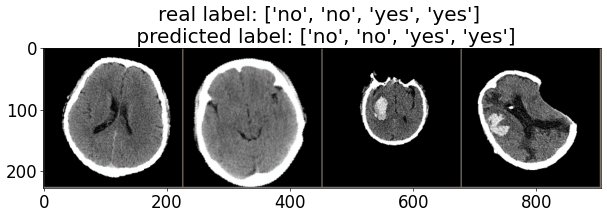

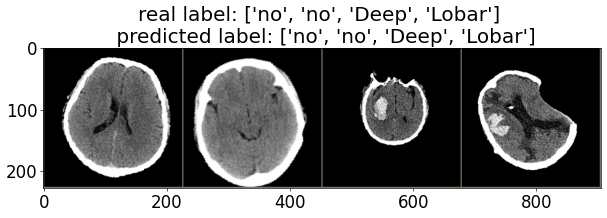

[Test] Loss: 0.0103 Acc: 99.8677% Time: 10.3412s
TP: 1341
TN: 1681
FP: 0
FN: 1
deep count 606
lobar count 479
subtentorial count 596
positive count 1681
negative count 1342
TP: 1341
TN: 1681
FP: 0
FN: 1
Accuracy: 0.9996692027786966
Precision: 1.0
Recall: 0.9992548435171386
F1: 0.9996272828922848
Specificity: 1.0
C00: 599
C01: 0
C02: 6
C10: 0
C11: 480
C12: 0
C20: 0
C21: 0
C22: 596
Accuracy: 0.9964306960142773
Precision: 1.0
Recall: 0.9900826446280991
F1: 0.9950166112956811
Specificity: 1.0


In [15]:

home_dir='/disk2/jialiangfan/trained_models/'


# resnet model
model_name='dataset2-epoche_50-model_type_1-pretrained_False-argumentation_True-batch_size_32-optimizer_type-0.pth'
# model_name='dataset2-epoche_50-model_type_2-pretrained_False-argumentation_True-batch_size_32-optimizer_type-0.pth'

model_type=1
TP,TN,FP,FN, C00,C01,C02,C10,C11,C12,C20,C21,C22 =test(home_dir+model_name,model_type=model_type)

# draw the confusion matrix
print('TP:',TP)
print('TN:',TN)
print('FP:',FP)
print('FN:',FN)

print('Accuracy:',(TP+TN)/(TP+TN+FP+FN))
print('Precision:',TP/(TP+FP))
print('Recall:',TP/(TP+FN))
print('F1:',2*TP/(2*TP+FP+FN))
print('Specificity:',TN/(TN+FP))

print('C00:',C00)
print('C01:',C01)
print('C02:',C02)
print('C10:',C10)
print('C11:',C11)
print('C12:',C12)
print('C20:',C20)
print('C21:',C21)
print('C22:',C22)

print('Accuracy:',(C00+C11+C22)/(C00+C01+C02+C10+C11+C12+C20+C21+C22))
print('Precision:',C00/(C00+C10+C20))
print('Recall:',C00/(C00+C01+C02))
print('F1:',2*C00/(2*C00+C01+C02+C10+C20))
print('Specificity:',(C11+C22)/(C11+C12+C21+C22))

## VGG augumented

/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


label1: [0, 0, 1, 1]
preds1: [0, 0, 1, 1]
label2: [3, 3, 0, 1]
preds2: [3, 3, 0, 1]


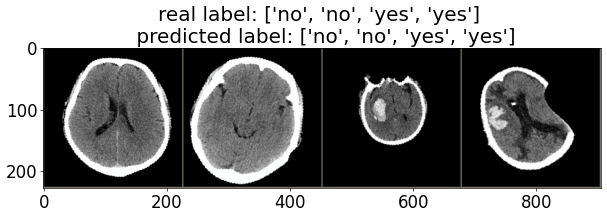

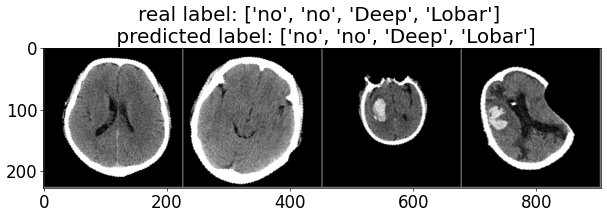

[Test] Loss: 0.0051 Acc: 99.9173% Time: 14.4126s
TP: 1342
TN: 1681
FP: 0
FN: 0
deep count 606
lobar count 479
subtentorial count 596
positive count 1681
negative count 1342
TP: 1342
TN: 1681
FP: 0
FN: 0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Specificity: 1.0
C00: 601
C01: 0
C02: 5
C10: 0
C11: 479
C12: 0
C20: 0
C21: 0
C22: 596
Accuracy: 0.9970255800118977
Precision: 1.0
Recall: 0.9917491749174917
F1: 0.995857497928749
Specificity: 1.0


In [16]:

home_dir='/disk2/jialiangfan/trained_models/'


# resnet model
model_name='dataset2-epoche_50-model_type_2-pretrained_False-argumentation_True-batch_size_32-optimizer_type-0.pth'
# model_name='dataset2-epoche_50-model_type_2-pretrained_False-argumentation_True-batch_size_32-optimizer_type-0.pth'
#  {0: ViT, 1: ResNet, 2:VGG16, 3:alexnet, 4:squeezenet, 5: ResNet34, 6: ResNet50,7:DenseNet}
model_type=2
TP,TN,FP,FN, C00,C01,C02,C10,C11,C12,C20,C21,C22 =test(home_dir+model_name,model_type=model_type)

# draw the confusion matrix
print('TP:',TP)
print('TN:',TN)
print('FP:',FP)
print('FN:',FN)

print('Accuracy:',(TP+TN)/(TP+TN+FP+FN))
print('Precision:',TP/(TP+FP))
print('Recall:',TP/(TP+FN))
print('F1:',2*TP/(2*TP+FP+FN))
print('Specificity:',TN/(TN+FP))

print('C00:',C00)
print('C01:',C01)
print('C02:',C02)
print('C10:',C10)
print('C11:',C11)
print('C12:',C12)
print('C20:',C20)
print('C21:',C21)
print('C22:',C22)

print('Accuracy:',(C00+C11+C22)/(C00+C01+C02+C10+C11+C12+C20+C21+C22))
print('Precision:',C00/(C00+C10+C20))
print('Recall:',C00/(C00+C01+C02))
print('F1:',2*C00/(2*C00+C01+C02+C10+C20))
print('Specificity:',(C11+C22)/(C11+C12+C21+C22))

## Draw the confusion matrix